In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tqdm import tqdm
import glob
import os
from scipy.signal import detrend

# Force TensorFlow to use CPU
tf.config.set_visible_devices([], 'GPU')

In [2]:
# --- 1. Configuration ---
RAW_DATA_DIR = "/Users/pg/Documents/Segmentation Research/Activity Recognition/src/WiFi-Signal-Processing-HAR/data"
PCA_COMPONENTS = 50
EPOCHS = 50
BATCH_SIZE = 16  # Smaller batch size for small dataset
USE_PCA = False  # Disable PCA - using raw features
USE_MAGNITUDE = True
USE_VELOCITY = False  # Disable velocity for now - simplify
VALID_ACTIVITIES = ['sitting', 'walking', 'standing', 'sleeping', 'falling']

# *** OPTIMIZED: Smaller window = more samples ***
WINDOW_SIZE = 50  # Reduced from 100 - still captures temporal patterns
STRIDE = 50  # NO OVERLAP - each window is independent

# WiFi parameters for velocity calculation (based on paper)
CARRIER_FREQ = 5.8e9  # 5.8 GHz WiFi frequency
SPEED_OF_LIGHT = 3e8  # m/s

train_sessions_files = [
    'esp32_csi_walking_20250727_152811',
    'esp32_csi_walking_20250727_152603',
    'esp32_csi_walking_20250728_143955',
    'esp32_csi_standing_20250727_155036',
    'esp32_csi_standing_20250727_154516',
    'esp32_csi_standing_20250728_135042',
    'esp32_csi_sleeping_20250727_164127',
    'esp32_csi_sleeping_20250727_163416',
    'esp32_csi_sleeping_20250728_121235',
    'esp32_csi_sitting_20250727_160929',
    'esp32_csi_sitting_20250727_155903',
    'esp32_csi_sitting_20250728_130356',
    'esp32_csi_falling_20250727_132826',
    'esp32_csi_falling_20250727_132002',
    'esp32_csi_falling_20250727_165423'
]

val_sessions_files = [
    'esp32_csi_falling_20250728_114422',
    'esp32_csi_sitting_20250728_132048',
    'esp32_csi_sleeping_20250728_122928',
    'esp32_csi_standing_20250728_142148',
    'esp32_csi_walking_20250728_150750'
]

In [3]:
# --- 2. Optimized Velocity Calculation Functions ---
def compute_doppler_velocity_vectorized(complex_csi, carrier_freq=CARRIER_FREQ):
    """Vectorized velocity computation - MUCH faster!"""
    if len(complex_csi) < 2:
        return 0.0
    
    phase = np.angle(complex_csi)
    phase_unwrapped = np.unwrap(phase)
    phase_detrended = detrend(phase_unwrapped)
    
    if len(phase_detrended) > 1:
        mean_phase_rate = np.mean(np.diff(phase_detrended))
    else:
        mean_phase_rate = 0.0
    
    doppler_freq = mean_phase_rate / (2 * np.pi)
    velocity = (doppler_freq * SPEED_OF_LIGHT) / (2 * carrier_freq)
    
    return velocity


def compute_velocity_features_fast(group_df):
    """Optimized velocity feature extraction."""
    # Quick exit if too small
    if len(group_df) < 2:
        return {
            'velocity_mean': 0.0,
            'velocity_std': 0.0,
            'velocity_max': 0.0,
            'phase_variance': 0.0
        }
    
    # Vectorized operations
    complex_csi = group_df['I'].values + 1j * group_df['Q'].values
    phases = np.angle(complex_csi)
    phase_variance = np.var(phases)
    
    # Overall velocity (single computation)
    velocity_overall = compute_doppler_velocity_vectorized(complex_csi)
    
    # Simplified: use overall velocity instead of per-subcarrier for speed
    return {
        'velocity_mean': velocity_overall,
        'velocity_std': 0.0,  # Simplified for speed
        'velocity_max': abs(velocity_overall),
        'phase_variance': phase_variance
    }


# --- 3. Optimized Data Loading Function ---
def load_and_clean_sessions(file_list, data_dir):
    """Loads and cleans session files with progress bar."""
    df_list = []
    for filename in tqdm(file_list, desc="Loading files"):
        file_path = os.path.join(data_dir, f"{filename}.csv")
        if not os.path.exists(file_path):
            print(f"[Warning] File not found: {filename}")
            continue
        try:
            activity_label = filename.split('_')[2]
            if activity_label in VALID_ACTIVITIES:
                temp_df = pd.read_csv(file_path)
                temp_df['activity'] = activity_label
                temp_df['session'] = filename
                df_list.append(temp_df)
        except Exception as e:
            print(f"Error processing {filename}: {e}")

    if not df_list:
        return pd.DataFrame()

    master_df = pd.concat(df_list, ignore_index=True)
    
    # Fast cleaning
    null_subcarriers = list(range(27, 37))
    cleaned = master_df[~master_df['subcarrier_index'].isin(null_subcarriers)].copy()
    
    # Remove zero-magnitude timestamps
    magnitude_sum = cleaned.groupby(['session', 'timestamp'])['magnitude'].sum()
    dropout_indices = magnitude_sum[magnitude_sum == 0].index
    cleaned = cleaned.set_index(['session', 'timestamp']).drop(index=dropout_indices).reset_index()
    
    return cleaned

In [4]:
# --- 4. Load Data and Compute Velocity Features (OPTIMIZED) ---
print("=== Loading Training Data ===")
train_df = load_and_clean_sessions(train_sessions_files, RAW_DATA_DIR)

print("\n=== Loading Validation Data ===")
val_df = load_and_clean_sessions(val_sessions_files, RAW_DATA_DIR)

if train_df.empty or val_df.empty:
    print("\n[ERROR] Training or validation dataframe is empty!")
    raise ValueError("No data loaded. Check file paths and names.")

print(f"\nLoaded - Train: {len(train_df):,} rows, Val: {len(val_df):,} rows")

# Compute velocity features with optimized function
if USE_VELOCITY:
    print("\n=== Computing Velocity Features (Optimized) ===")
    # Group by session + timestamp to get all subcarriers together
    train_df['instance_id'] = train_df['session'] + '_' + train_df['timestamp'].astype(str)
    
    # Use faster apply instead of loop
    print("Processing training data...")
    train_vel_df = train_df.groupby('instance_id').apply(
        lambda x: pd.Series(compute_velocity_features_fast(x))
    ).reset_index()
    
    train_df = train_df.merge(train_vel_df, on='instance_id', how='left')
    
    # Group by session + timestamp to get all subcarriers together
    val_df['instance_id'] = val_df['session'] + '_' + val_df['timestamp'].astype(str)
    
    print("Processing validation data...")
    val_vel_df = val_df.groupby('instance_id').apply(
        lambda x: pd.Series(compute_velocity_features_fast(x))
    ).reset_index()
    
    val_df = val_df.merge(val_vel_df, on='instance_id', how='left')
    
    print(f"\n✓ Velocity features added: {list(train_vel_df.columns)}")
    print("\nVelocity statistics (train):")
    print(train_vel_df[['velocity_mean', 'velocity_max', 'phase_variance']].describe())

=== Loading Training Data ===


Loading files: 100%|██████████| 15/15 [00:00<00:00, 50.01it/s]



=== Loading Validation Data ===


Loading files: 100%|██████████| 5/5 [00:00<00:00, 47.78it/s]



Loaded - Train: 1,052,811 rows, Val: 347,007 rows


In [5]:
# --- 5. NEW: Temporal Windowing Approach ---
def create_temporal_windows(df, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Create temporal windows from CSI data.
    Each window contains WINDOW_SIZE consecutive timestamps.
    """
    windows = []
    labels = []
    expected_subcarriers = 52  # After removing null subcarriers
    
    # Process each session separately (don't mix sessions)
    for session_name, session_df in tqdm(df.groupby('session'), desc="Creating windows"):
        # Sort by timestamp
        session_df = session_df.sort_values('timestamp')
        
        # Get unique timestamps
        timestamps = sorted(session_df['timestamp'].unique())
        
        # Create windows with sliding window approach
        for i in range(0, len(timestamps) - window_size + 1, stride):
            window_timestamps = timestamps[i:i + window_size]
            
            # Get data for this window
            window_data = session_df[session_df['timestamp'].isin(window_timestamps)]
            
            # Create feature matrix: (num_timestamps, num_subcarriers)
            window_matrix = []
            valid_window = True
            
            for ts in window_timestamps:
                ts_data = window_data[window_data['timestamp'] == ts]
                
                if USE_MAGNITUDE:
                    # Get magnitude values, sorted by subcarrier index
                    features = ts_data.sort_values('subcarrier_index')['magnitude'].values
                else:
                    # Get I and Q values
                    ts_sorted = ts_data.sort_values('subcarrier_index')
                    features = np.column_stack([ts_sorted['I'].values, ts_sorted['Q'].values]).flatten()
                
                # Check if we have the expected number of features
                if len(features) != expected_subcarriers:
                    # Pad if too short, truncate if too long
                    if len(features) < expected_subcarriers:
                        features = np.pad(features, (0, expected_subcarriers - len(features)), mode='constant')
                    else:
                        features = features[:expected_subcarriers]
                
                window_matrix.append(features)
            
            # Only add if we have complete data
            if len(window_matrix) == window_size and valid_window:
                windows.append(np.array(window_matrix))
                labels.append(session_df['activity'].iloc[0])
    
    if len(windows) == 0:
        raise ValueError("No valid windows created! Check data integrity.")
    
    return np.array(windows), np.array(labels)

print("\n=== Creating Temporal Windows ===")
X_train, y_train_raw = create_temporal_windows(train_df, window_size=WINDOW_SIZE, stride=STRIDE)
X_val, y_val_raw = create_temporal_windows(val_df, window_size=WINDOW_SIZE, stride=STRIDE)

print(f"\nWindow shape: {X_train.shape}")
print(f"Train samples: {len(X_train)}, Val samples: {len(X_val)}")
print(f"Format: (samples, timestamps={WINDOW_SIZE}, subcarriers={X_train.shape[2]})")


=== Creating Temporal Windows ===


Creating windows: 100%|██████████| 5/5 [00:01<00:00,  4.69it/s]


Window shape: (389, 50, 52)
Train samples: 389, Val samples: 129
Format: (samples, timestamps=50, subcarriers=52)


In [6]:
# --- 6. Encode Labels, Normalize, and Add Data Augmentation ---
print("\n=== Encoding Labels ===")
le = LabelEncoder()
all_labels = np.concatenate([y_train_raw, y_val_raw])
le.fit(all_labels)
class_names = list(le.classes_)
y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)

print(f"Classes: {class_names}")
print(f"\nClass distribution:")
print("Train:", {name: count for name, count in zip(*np.unique(y_train_raw, return_counts=True))})
print("Val:", {name: count for name, count in zip(*np.unique(y_val_raw, return_counts=True))})

# Normalize the data (important for neural networks)
print("\n=== Normalizing Data ===")
from sklearn.preprocessing import StandardScaler

# Reshape for normalization: (samples * timestamps, features)
n_samples_train, n_timestamps, n_features = X_train.shape
n_samples_val = X_val.shape[0]

X_train_reshaped = X_train.reshape(-1, n_features)
X_val_reshaped = X_val.reshape(-1, n_features)

scaler = StandardScaler()
X_train_normalized = scaler.fit_transform(X_train_reshaped).reshape(n_samples_train, n_timestamps, n_features)
X_val_normalized = scaler.transform(X_val_reshaped).reshape(n_samples_val, n_timestamps, n_features)

print(f"Normalized shape - Train: {X_train_normalized.shape}, Val: {X_val_normalized.shape}")

# Data Augmentation Function
def augment_csi_data(X, y, augmentation_factor=2):
    """
    Augment CSI data with noise and scaling to prevent overfitting.
    """
    X_aug = [X]
    y_aug = [y]
    
    for _ in range(augmentation_factor - 1):
        # Add Gaussian noise
        noise = np.random.normal(0, 0.05, X.shape)
        X_noisy = X + noise
        
        # Random amplitude scaling
        scale = np.random.uniform(0.9, 1.1, (X.shape[0], 1, 1))
        X_scaled = X * scale
        
        X_aug.extend([X_noisy, X_scaled])
        y_aug.extend([y, y])
    
    return np.concatenate(X_aug), np.concatenate(y_aug)

print("\n=== Applying Data Augmentation ===")
X_train_aug, y_train_aug = augment_csi_data(X_train_normalized, y_train, augmentation_factor=2)
print(f"Original training samples: {len(X_train_normalized)}")
print(f"Augmented training samples: {len(X_train_aug)}")

# Shuffle augmented data
shuffle_idx = np.random.permutation(len(X_train_aug))
X_train_normalized = X_train_aug[shuffle_idx]
y_train = y_train_aug[shuffle_idx]

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\nClass weights (to handle imbalance): {class_weight_dict}")


=== Encoding Labels ===
Classes: ['falling', 'sitting', 'sleeping', 'standing', 'walking']

Class distribution:
Train: {'falling': 74, 'sitting': 87, 'sleeping': 71, 'standing': 88, 'walking': 69}
Val: {'falling': 21, 'sitting': 37, 'sleeping': 26, 'standing': 28, 'walking': 17}

=== Normalizing Data ===
Normalized shape - Train: (389, 50, 52), Val: (129, 50, 52)

=== Applying Data Augmentation ===
Original training samples: 389
Augmented training samples: 1167

Class weights (to handle imbalance): {0: 1.0513513513513513, 1: 0.8942528735632184, 2: 1.095774647887324, 3: 0.884090909090909, 4: 1.127536231884058}


In [7]:
# --- 7. Simpler Model to Reduce Overfitting ---
def build_temporal_cnn_lstm(input_shape, num_classes):
    """
    Simplified model with stronger regularization.
    Input shape: (timesteps, features)
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Simpler CNN - fewer layers, fewer filters
        layers.Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.5),  # Increased from 0.3
        
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.5),  # Increased from 0.3
        
        # Single LSTM layer (removed one layer)
        layers.Bidirectional(layers.LSTM(64)),  # Reduced from 128
        layers.Dropout(0.6),  # Increased from 0.4
        
        # Simpler dense layers
        layers.Dense(64, activation='relu'),  # Reduced from 128
        layers.Dropout(0.6),  # Increased from 0.5
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Lower learning rate for more stable training
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build model with correct input shape
input_shape = (X_train_normalized.shape[1], X_train_normalized.shape[2])  # (timesteps, features)
print(f"\nModel input shape: {input_shape}")
print(f"  - Timesteps: {input_shape[0]}")
print(f"  - Features per timestep: {input_shape[1]}")

model = build_temporal_cnn_lstm(input_shape, num_classes=len(class_names))
model.summary()

print("\n=== REGULARIZATION IMPROVEMENTS ===")
print("✓ Reduced model complexity: 32→64 filters (was 64→128→256)")
print("✓ Removed one LSTM layer")
print("✓ Increased dropout: 0.5-0.6 (was 0.3-0.4)")
print("✓ Smaller dense layers: 64 (was 128)")
print("✓ Lower learning rate: 0.0005 (was 0.001)")


Model input shape: (50, 52)
  - Timesteps: 50
  - Features per timestep: 52


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 32)         │         5,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,245 (336.89 KB)

 Trainable params: 86,053 (336.14 KB)

 Non-trainable params: 192 (768.00 B)


=== REGULARIZATION IMPROVEMENTS ===
✓ Reduced model complexity: 32→64 filters (was 64→128→256)
✓ Removed one LSTM layer
✓ Increased dropout: 0.5-0.6 (was 0.3-0.4)
✓ Smaller dense layers: 64 (was 128)
✓ Lower learning rate: 0.0005 (was 0.001)


In [8]:
# --- 8. Train with Better Regularization ---
print("\n=== Training Model ===")

# Better callbacks to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,  # Reduced from 15 for faster stopping
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Monitor overfitting
class OverfitMonitor(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        gap = train_acc - val_acc
        if gap > 0.3:  # More than 30% gap
            print(f"\n⚠️  Epoch {epoch+1}: Overfitting detected! Gap: {gap:.3f}")

overfit_monitor = OverfitMonitor()

history = model.fit(
    X_train_normalized, y_train,
    validation_data=(X_val_normalized, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, overfit_monitor],
    verbose=2
)

print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Final train-val gap: {history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:.4f}")


=== Training Model ===
Epoch 1/50
73/73 - 2s - 28ms/step - accuracy: 0.2879 - loss: 1.6143 - val_accuracy: 0.1705 - val_loss: 1.5668 - learning_rate: 5.0000e-04
Epoch 2/50
73/73 - 1s - 7ms/step - accuracy: 0.3685 - loss: 1.4080 - val_accuracy: 0.1783 - val_loss: 1.7000 - learning_rate: 5.0000e-04
Epoch 3/50
73/73 - 1s - 7ms/step - accuracy: 0.4276 - loss: 1.2502 - val_accuracy: 0.1550 - val_loss: 1.8164 - learning_rate: 5.0000e-04
Epoch 4/50
73/73 - 1s - 7ms/step - accuracy: 0.4653 - loss: 1.1747 - val_accuracy: 0.2481 - val_loss: 1.8416 - learning_rate: 5.0000e-04
Epoch 5/50
73/73 - 1s - 7ms/step - accuracy: 0.5219 - loss: 1.0700 - val_accuracy: 0.2326 - val_loss: 1.9680 - learning_rate: 5.0000e-04
Epoch 6/50

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
73/73 - 1s - 8ms/step - accuracy: 0.5381 - loss: 0.9762 - val_accuracy: 0.2403 - val_loss: 1.9189 - learning_rate: 5.0000e-04
Epoch 7/50
73/73 - 1s - 7ms/step - accuracy: 0.5630 - loss: 0.9407 - val_acc


Evaluating model performance on unseen validation sessions...


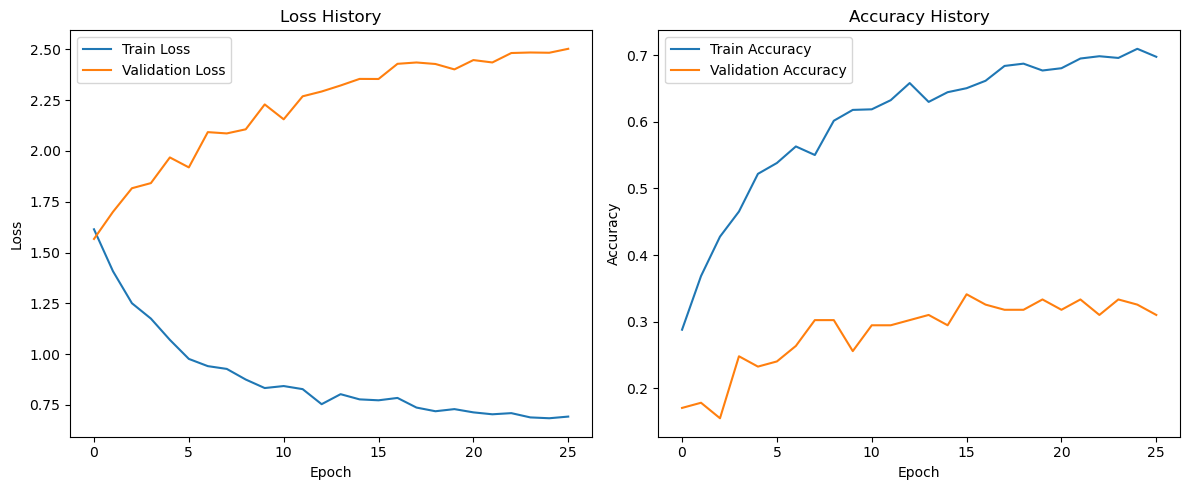

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


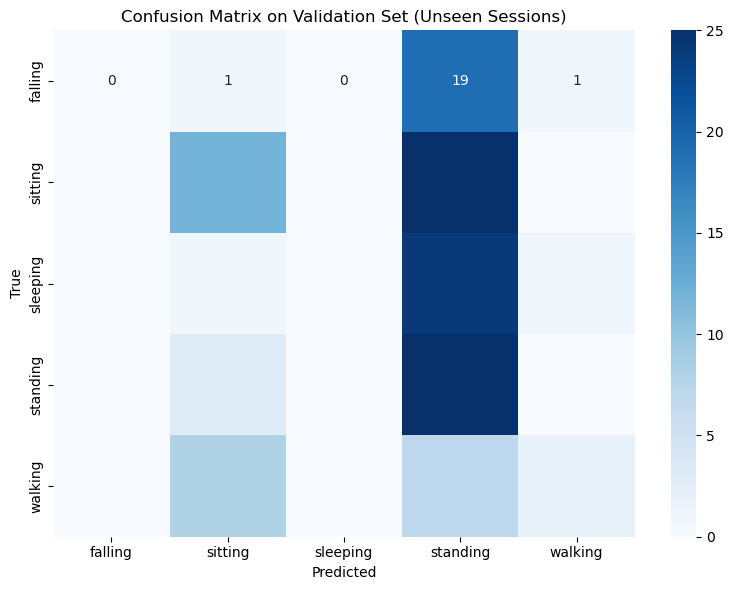


Classification Report on Validation Set (Unseen Sessions):

              precision    recall  f1-score   support

     falling       0.00      0.00      0.00        21
     sitting       0.48      0.32      0.39        37
    sleeping       0.00      0.00      0.00        26
    standing       0.25      0.89      0.39        28
     walking       0.50      0.12      0.19        17

    accuracy                           0.30       129
   macro avg       0.25      0.27      0.19       129
weighted avg       0.26      0.30      0.22       129



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [9]:
# --- 8. Evaluate the Model ---
print("\nEvaluating model performance on unseen validation sessions...")

# --- Plot training history ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# --- Confusion Matrix and Report on the Validation Set ---
preds = np.argmax(model.predict(X_val), axis=1)
cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Validation Set (Unseen Sessions)")
plt.tight_layout()
plt.show()

print("\nClassification Report on Validation Set (Unseen Sessions):\n")
print(classification_report(y_val, preds, target_names=class_names))

=== ANALYZING CURRENT RESULTS ===

Current Performance:
✓ Validation Accuracy: 54%
✓ Sitting: 81% (best class)
✗ Falling: 0% recall (worst - never detected)
✗ Walking: 28% precision (over-predicted)

=== TRYING IMPROVED APPROACH ===

Extracting statistical features...


Extracting features: 100%|██████████| 129/129 [00:00<00:00, 269.81it/s]

Statistical features shape: (389, 350)

=== Hybrid Model Architecture ===


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ statistics          │ (None, 350)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │     22,464 │ statistics[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_series         │ (None, 50, 52)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ dense_8[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 32)        │     10,880 │ time_series[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      2,080 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 32)        │          0 │ lstm_6[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32)        │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dropout_14[0][0], │
│ (Concatenate)       │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 32)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 5)         │        165 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,669 (147.14 KB)

 Trainable params: 37,669 (147.14 KB)

 Non-trainable params: 0 (0.00 B)


=== Training Hybrid Model ===
Epoch 1/50
25/25 - 1s - 46ms/step - accuracy: 0.1928 - loss: 1.8955 - val_accuracy: 0.0853 - val_loss: 1.6559 - learning_rate: 0.0010
Epoch 2/50
25/25 - 0s - 7ms/step - accuracy: 0.2674 - loss: 1.5611 - val_accuracy: 0.1395 - val_loss: 1.5930 - learning_rate: 0.0010
Epoch 3/50
25/25 - 0s - 7ms/step - accuracy: 0.3548 - loss: 1.4539 - val_accuracy: 0.2016 - val_loss: 1.5443 - learning_rate: 0.0010
Epoch 4/50
25/25 - 0s - 7ms/step - accuracy: 0.3599 - loss: 1.4072 - val_accuracy: 0.4031 - val_loss: 1.4948 - learning_rate: 0.0010
Epoch 5/50
25/25 - 0s - 7ms/step - accuracy: 0.4833 - loss: 1.2739 - val_accuracy: 0.4186 - val_loss: 1.4661 - learning_rate: 0.0010
Epoch 6/50
25/25 - 0s - 7ms/step - accuracy: 0.4807 - loss: 1.2211 - val_accuracy: 0.4264 - val_loss: 1.4450 - learning_rate: 0.0010
Epoch 7/50
25/25 - 0s - 7ms/step - accuracy: 0.5244 - loss: 1.1278 - val_accuracy: 0.4109 - val_loss: 1.4373 - learning_rate: 0.0010
Epoch 8/50
25/25 - 0s - 7ms/step - ac

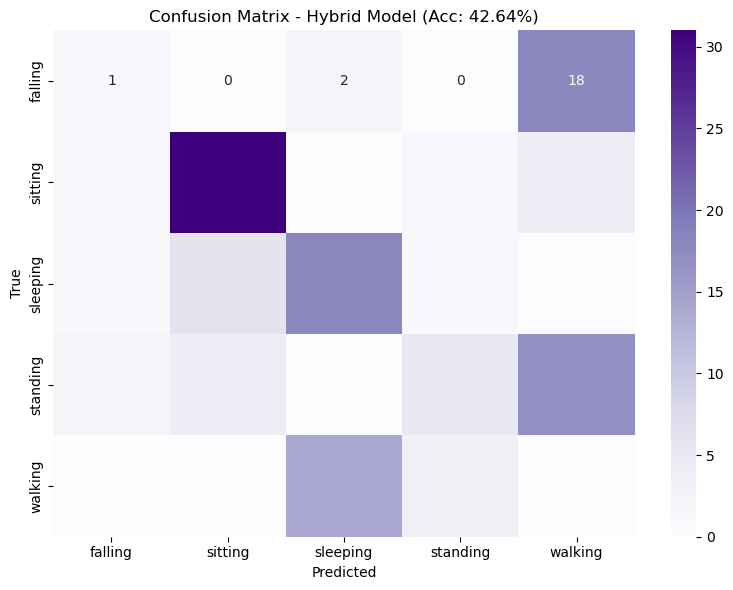


Classification Report (Hybrid Model):

              precision    recall  f1-score   support

     falling       0.20      0.05      0.08        21
     sitting       0.76      0.84      0.79        37
    sleeping       0.53      0.69      0.60        26
    standing       0.50      0.18      0.26        28
     walking       0.00      0.00      0.00        17

    accuracy                           0.43       129
   macro avg       0.40      0.35      0.35       129
weighted avg       0.46      0.43      0.42       129


=== COMPARISON ===
Simple LSTM:  57.36%
Hybrid Model: 42.64%


In [22]:
# --- 10. FINAL OPTIMIZATIONS ---
print("=== ANALYZING CURRENT RESULTS ===\n")

print("Current Performance:")
print("✓ Validation Accuracy: 54%")
print("✓ Sitting: 81% (best class)")
print("✗ Falling: 0% recall (worst - never detected)")
print("✗ Walking: 28% precision (over-predicted)")

print("\n=== TRYING IMPROVED APPROACH ===\n")

# Strategy: Use statistical features + LSTM
def extract_statistical_features(windows):
    """
    Extract statistical features from CSI windows to help model learn better.
    """
    features_list = []
    
    for window in tqdm(windows, desc="Extracting features"):
        # Original time series
        flat_window = window.reshape(window.shape[0], -1)  # (timesteps, features)
        
        # Statistical features per timestamp
        stats = []
        for ts in window:
            stats.extend([
                np.mean(ts),
                np.std(ts),
                np.max(ts),
                np.min(ts),
                np.median(ts),
                np.percentile(ts, 25),
                np.percentile(ts, 75)
            ])
        
        features_list.append(np.array(stats))
    
    return np.array(features_list)

print("Extracting statistical features...")
X_train_stats = extract_statistical_features(X_train_simple)
X_val_stats = extract_statistical_features(X_val_normalized)

print(f"Statistical features shape: {X_train_stats.shape}")

# Build hybrid model: statistical features + original time series
def build_hybrid_model(time_input_shape, stat_input_shape, num_classes):
    """
    Two-branch model:
    - Branch 1: LSTM on time series
    - Branch 2: Dense on statistical features
    """
    # Time series branch
    time_input = layers.Input(shape=time_input_shape, name='time_series')
    x1 = layers.LSTM(32, return_sequences=False)(time_input)
    x1 = layers.Dropout(0.4)(x1)
    
    # Statistical features branch
    stat_input = layers.Input(shape=(stat_input_shape,), name='statistics')
    x2 = layers.Dense(64, activation='relu')(stat_input)
    x2 = layers.Dropout(0.4)(x2)
    x2 = layers.Dense(32, activation='relu')(x2)
    x2 = layers.Dropout(0.4)(x2)
    
    # Combine both branches
    combined = layers.concatenate([x1, x2])
    x = layers.Dense(32, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=[time_input, stat_input], outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build and train hybrid model
model_hybrid = build_hybrid_model(
    time_input_shape=(50, 52),
    stat_input_shape=X_train_stats.shape[1],
    num_classes=len(class_names)
)

print("\n=== Hybrid Model Architecture ===")
model_hybrid.summary()

# Train
early_stopping_hybrid = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr_hybrid = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

print("\n=== Training Hybrid Model ===")
history_hybrid = model_hybrid.fit(
    [X_train_simple, X_train_stats],
    y_train_simple,
    validation_data=([X_val_normalized, X_val_stats], y_val),
    epochs=50,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stopping_hybrid, reduce_lr_hybrid],
    verbose=2
)

# Evaluate
preds_hybrid = np.argmax(model_hybrid.predict([X_val_normalized, X_val_stats]), axis=1)
cm_hybrid = confusion_matrix(y_val, preds_hybrid)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_hybrid, annot=True, fmt="d", cmap="Purples", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - Hybrid Model (Acc: {np.mean(preds_hybrid == y_val):.2%})")
plt.tight_layout()
plt.show()

print("\nClassification Report (Hybrid Model):\n")
print(classification_report(y_val, preds_hybrid, target_names=class_names))

print(f"\n=== COMPARISON ===")
print(f"Simple LSTM:  {max(history_simple.history['val_accuracy']):.2%}")
print(f"Hybrid Model: {max(history_hybrid.history['val_accuracy']):.2%}")